
## Bayesian Linear Regression

#### Ryan McGuigan
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

Traditional linear regression provides point estimates for coefficients with measures of certainty defined by standard error calculations. As additional data is incorporated and parameters are updated, historical uncertainty measurements are typically discarded or inadequately preserved. This workflow implements a Bayesian Linear Regression framework using MCMC sampling to track the evolution of model uncertainty as the dataset grows. A synthetic dataset with known true parameters is generated and progressively segmented to simulate realistic data accumulation. At each stage, both OLS and Bayesian models are fitted and compared against the known ground truth.

The main findings show that Bayesian posteriors provide substantially richer information about parameter uncertainty while achieving comparable predictive performance to OLS once sufficient data is available. The Bayesian framework retains the complete probabilistic history, which would be valuable for decision-making under uncertainty.

In oil and gas operations, significant capital allocation decisions often rely on OLS regression due to simplicity and ease of communication to management. However, OLS produces only point estimates, providing no quantitative measure of confidence in predictions or characterization of outcome ranges. Bayesian regression addresses this gap by generating full posterior distributions that explicitly quantify parameter uncertainty, enabling more rigorous risk assessment and better-informed investment decisions.

### Import Packages


In [ ]:
import warnings
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from scipy.stats import multivariate_normal
from scipy.stats import invgamma

# set plotting style
plt.style.use('default')
np.random.seed(383)
warnings.filterwarnings("ignore", category=UserWarning)

print('libraries imported')

libraries imported


### Bayesian Linear Regression Class

Implementation of Bayesian Linear Regression using Metropolis-Hastings MCMC sampler. The class handles prior specification, posterior sampling, and prediction with uncertainty quantification.

Instead of finding single best-fit coefficients like ordinary least squares, Bayesian regression explores the all possibilites of coefficient values. It is a random walk through parameter space. Starting with an initial naive estimate, then repeatedly proposing small changes to the parameters. If a proposed change makes the model fit better, it is accepted. If it makes the fit worse, it is sometimes rejected based on a probability measure. This randomness prevents the algorithm from getting stuck and allows for exploration of less likely explanations. After many iterations, the collection of accepted parameters forms a distribution that represents uncertainty about the true values.

Helper functions within the class:
<br><br>

**Log-Likelihood**: <br>
Measures how well the current parameters, β coefficients and σ² noise, explain the observed data. Higher likelihood means the model predictions are closer to actual observations. Calculated assuming normally distributed errors. Following Pyrcz (2024), the likelihood density for the response given predictors and model parameters is:

$$Y \sim \mathcal{N}(\beta^T X, \sigma^2 I)$$

where under independence we calculate the product sum over all training data:

$$f(y,X|\beta) = \prod_{\alpha=1}^{n}f_{y,X|\beta}(y_\alpha)$$

In log space, where the log of a product becomes a summation and because any log value between 0 and 1 is a negative number, it allows for convenient minimization.

$$\log p(y|X, \beta, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - X_i\beta)^2$$

where $n$ is the number of observations, $y$ is the response, $X$ are the predictor features, $\beta$ is the coefficient vector, and $\sigma^2$ is the noise variance.
<br><br><br>


**Log-Prior**: <br>
Our initial beliefs about parameters before seeing data (DO NOT LEAK OBSERVATIONS FROM THE DATA INTO THE PRIOR!). Uses a normal prior for coefficients (centered at zero with specified variance) and inverse-gamma prior for noise variance. The **inverse-gamma** has the convenient property that, when combined with a normal liklehood function, produces a normal posterior distribution (i.e., conjugate).

$$\log p(\beta, \sigma^2) = -\frac{1}{2\sigma_\beta^2}\sum_{j=1}^{p}\beta_j^2 - 2.5\log(\sigma^2) - \frac{1}{\sigma^2}$$

where $\sigma_\beta^2$ is the prior variance for coefficients, $p$ is the number of predictors, and the second term represents the inverse-gamma prior on $\sigma^2$.
<br><br><br>


**Metropolis-Hastings Step**: <br>
Core MCMC algorithm that proposes new parameter values and decides whether to accept or reject them. The algorithm will test a new set of a coefficents, stepping away from the previous value (Markov Propertiy) by a small random amount (Monte Carlo process) and then test if these new parameters better describe the data. If it does, we keep those coefficents for our posterior distribution. If it does not, we keep a portion of them based on a liklihood ratio

$$P(\beta \rightarrow \beta')
= \min\left(
\frac{p(y, X \mid \beta')\, p(\beta')}{p(y, X \mid \beta)\, p(\beta)},\; 1
\right)
$$

Note: the evidence terms $p(y,X)$ cancel out in the ratio. In log space for stability:

$$\ln P(\beta \rightarrow \beta') = \min\left(\left[\ln f(y,X \mid \beta') + \ln f(\beta')\right]
-\left[\ln f(y,X \mid \beta) + \ln f(\beta)\right],\; 0\right)
$$

where $\beta'$ is the proposed parameter and $\beta$ is the current parameter.
<br><br><br>

**Fitting**: <br>
Initializes parameters with naive small random values (no data leakage), then runs the MCMC chain for a specified number of iterations. The first portion (burn-in) is discarded to allow the chain to reach stationarity (constant statistical properties across the chain). Remaining samples approximate the posterior.
<br><br><br>


**Prediction**: <br>
Uses posterior samples to generate predictions. For each test point, calculates predictions using all posterior parameter samples, then summarizes with mean and standard deviation. This captures both parameter uncertainty and inherent noise.

$$\hat{y} = \frac{1}{S}\sum_{s=1}^{S}X\beta^{(s)}, \quad \text{SD}(\hat{y}) = \sqrt{\frac{1}{S-1}\sum_{s=1}^{S}(X\beta^{(s)} - \hat{y})^2}$$

where $S$ is the number of posterior samples and $\beta^{(s)}$ is the coefficient vector from sample $s$.


**Reference**: Pyrcz, M.J., 2024, Applied Machine Learning in Python: A Hands-on Guide with Code, Bayesian Linear Regression chapter. [https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_Bayesian_linear_regression.html](https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_Bayesian_linear_regression.html)

In [ ]:
class BayesianLinearRegression:
    def __init__(self, feature_names: list, prior_var: float = 10.0):
        """bayesian linear regression with MCMC sampling
        feature_names: list, names of features for tracking
        prior_var: float, prior variance for coefficients
        
        Custom implementation to demonstrate the burn-in period and MCMC
        sampling process. The SKLearn BayesianRidge was considered, but
        it's analytical solution did not allow for the same level of educational
        exploration.
        """
        self.feature_names = ['Intercept'] + feature_names
        self.prior_var = prior_var
        self.samples = None
        self.fitted = False
        
    def _log_likelihood(self, beta: np.ndarray, sigma2: float, X: np.ndarray, y: np.ndarray) -> float:
        """calculate log likelihood of data given parameters"""
        pred = X @ beta
        resid = y - pred
        n = len(y)
        ll = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(resid**2) / sigma2
        return ll
    
    def _log_prior(self, beta: np.ndarray, sigma2: float) -> float:
        """calculate log prior probability of parameters"""
        # normal prior for beta
        lp_beta = -0.5 * np.sum(beta**2) / self.prior_var
        # inverse gamma prior for sigma2
        lp_sigma2 = -2.5 * np.log(sigma2) - 1.0 / sigma2
        return lp_beta + lp_sigma2
    
    def _metropolis_step(self, beta_curr: np.ndarray, sigma2_curr: float, X: np.ndarray, y: np.ndarray, 
                        beta_step: float, sigma2_step: float) -> tuple:
        """single metropolis-hastings step"""
        # propose new values
        beta_prop = beta_curr + np.random.normal(0, beta_step, size=len(beta_curr))
        sigma2_prop = sigma2_curr + np.random.normal(0, sigma2_step)
        
        if sigma2_prop <= 0:
            return beta_curr, sigma2_curr, False
        
        # calculate acceptance ratio
        log_r = (self._log_likelihood(beta_prop, sigma2_prop, X, y) + 
                 self._log_prior(beta_prop, sigma2_prop) -
                 self._log_likelihood(beta_curr, sigma2_curr, X, y) - 
                 self._log_prior(beta_curr, sigma2_curr))
        
        if np.log(np.random.rand()) < log_r:
            return beta_prop, sigma2_prop, True
        else:
            return beta_curr, sigma2_curr, False
    
    def fit(self, X: np.ndarray, y: np.ndarray, n_samples: int = 10000, n_burnin: int = 5000, 
            beta_step: float = 0.05, sigma2_step: float = 0.05):
        """fit bayesian model with MCMC sampling
        X: np.ndarray, feature matrix
        y: np.ndarray, response vector
        n_samples: int, total MCMC samples
        n_burnin: int, burn-in samples to discard
        beta_step: float, proposal step size for beta  (if too small, has trouble converging)
        sigma2_step: float, proposal step size for sigma2
        """
        # add intercept
        X_design = np.column_stack([np.ones(len(X)), X])
        n_features = X_design.shape[1]
        
        # initialize with naive values (no data leakage)
        beta_curr = np.random.normal(0, 1, size=n_features)
        sigma2_curr = 1.0
        
        # storage
        beta_samples = np.zeros((n_samples, n_features))
        sigma2_samples = np.zeros(n_samples)
        accept_count = 0
        
        # MCMC sampling
        for i in range(n_samples):
            beta_curr, sigma2_curr, accepted = self._metropolis_step(
                beta_curr, sigma2_curr, X_design, y, beta_step, sigma2_step
            )
            beta_samples[i] = beta_curr
            sigma2_samples[i] = sigma2_curr
            if accepted:
                accept_count += 1
        
        # store both full chain and posterior (post burn-in)
        self.samples = {'beta': beta_samples[n_burnin:],
                        'sigma2': sigma2_samples[n_burnin:],
                        'beta_full': beta_samples,
                        'sigma2_full': sigma2_samples,
                        'acceptance_rate': accept_count / n_samples,
                        'n_burnin': n_burnin,
                        'n_samples': n_samples}
        self.fitted = True
        
    def predict(self, X: np.ndarray, return_std: bool = False):
        """generate predictions from posterior
        X: np.ndarray, feature matrix for prediction
        return_std: bool, return standard deviation if True
        """
        if not self.fitted:
            raise ValueError('model not fitted')
        
        # prepare design matrix
        X_design = np.column_stack([np.ones(len(X)), X])
        predictions = X_design @ self.samples['beta'].T
        
        y_mean = predictions.mean(axis=1)
        if return_std:
            y_std = predictions.std(axis=1)
            return y_mean, y_std
        return y_mean
    
    def get_summary(self) -> pd.DataFrame:
        """summary statistics for posterior parameters"""
        if not self.fitted:
            raise ValueError('model not fitted')
        
        # calculate statistics
        beta_mean = self.samples['beta'].mean(axis=0)
        beta_std = self.samples['beta'].std(axis=0)
        beta_ci = np.percentile(self.samples['beta'], [2.5, 97.5], axis=0)
        
        sigma2_mean = self.samples['sigma2'].mean()
        sigma2_std = self.samples['sigma2'].std()
        
        summary = pd.DataFrame({'Parameter': self.feature_names + ['sigma2'],
                                'Mean': np.append(beta_mean, sigma2_mean),
                                'Std': np.append(beta_std, sigma2_std),
                                'CI_2.5': np.append(beta_ci[0], np.percentile(self.samples['sigma2'], 2.5)),
                                'CI_97.5': np.append(beta_ci[1], np.percentile(self.samples['sigma2'], 97.5))})
        
        return summary

print('bayesian class defined')

bayesian class defined


### Data Generation

Generate a synthetic dataset with 1,000 samples and known true parameters. This allows validation of the Bayesian regression against ground truth.

True parameters:
* **Feature 1**: coefficient = 5.0
* **Feature 2**: coefficient = 0.5  
* **Feature 3**: coefficient = 3.0
* **Response Variance**: σ² = 1.0

Feature covariance structure with correlations between predictors to represent realistic data relationships.

In [3]:
# true parameters
true_beta = np.array([5.0, 0.5, 3.0])
true_sigma2 = 1.0
n_samples = 1000

# feature covariance
feature_cov = np.array([[1.0, 0.3, 0.1],
                        [0.3, 1.0, 0.2],
                        [0.1, 0.2, 1.0]])

# generate correlated features
X = np.random.multivariate_normal(np.zeros(3), feature_cov, size=n_samples)

# generate response
y_true = X @ true_beta
y = y_true + np.random.normal(0, np.sqrt(true_sigma2), size=n_samples)

# create dataframe
data = pd.DataFrame(X, columns=['Feature1', 'Feature2', 'Feature3'])
data['Response'] = y

print(f'generated {n_samples} samples')
print(f'true parameters: β = {true_beta}, σ² = {true_sigma2}')
data.head()

generated 1000 samples
true parameters: β = [5.  0.5 3. ], σ² = 1.0


,Feature1,Feature2,Feature3,Response
0,1.442102,0.324420,1.265793,10.497394
1,0.820320,-0.147948,2.269949,9.256897
2,0.259401,-0.966223,0.672619,3.490382
3,1.108628,-1.705365,-0.370554,4.001246
4,-0.538509,0.292704,-0.795297,-3.981022


### Exploratory Data Analysis

Visualize the feature relationships and response variable distribution.

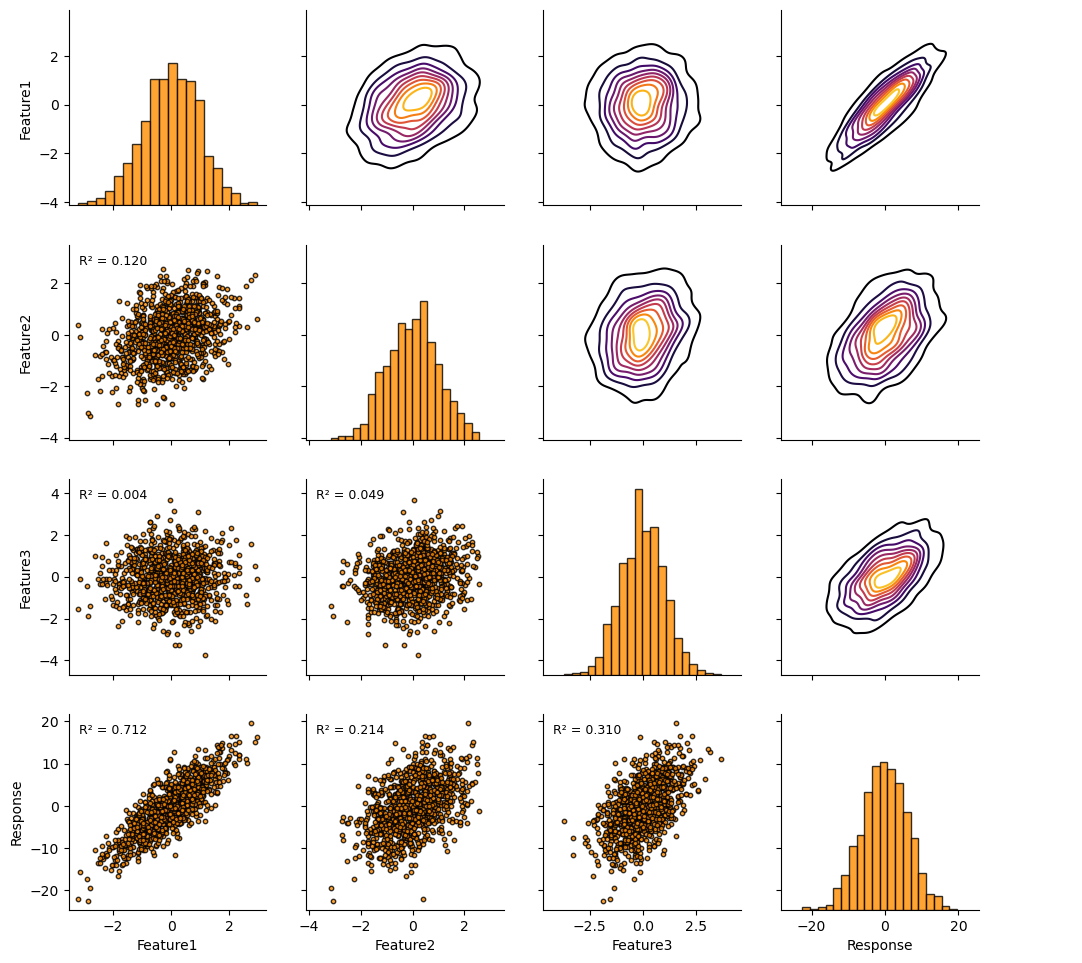

In [ ]:
# pairplot visualization adapted from pyrcz's multivariate analysis demonstrations
# see: https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_multivariate_analysis.html

def scatter_with_r2(x, y, **kwargs):
    plt.scatter(x, y, **kwargs)
    # calculate r²
    r2 = np.corrcoef(x, y)[0, 1]**2
    # add text annotation
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes,
             fontsize=9, verticalalignment='top')

pairgrid = sns.PairGrid(data, vars=['Feature1', 'Feature2', 'Feature3', 'Response'])
pairgrid = pairgrid.map_lower(scatter_with_r2, color='darkorange', edgecolor='black', alpha=0.8, s=10)
pairgrid = pairgrid.map_diag(plt.hist, bins=20, color='darkorange', alpha=0.8, edgecolor='k')
pairgrid = pairgrid.map_upper(sns.kdeplot, cmap=plt.cm.inferno, 
                               fill=False, alpha=1.0, levels=10)
pairgrid.add_legend()
plt.subplots_adjust(left=0.0, bottom=0.0, right=0.9, top=0.9, wspace=0.2, hspace=0.2)
plt.show()

### Sequential Data Stages

The dataset is partitioned into progressive stages to simulate data accumulation over time, reflecting real-world scenarios where initial datasets are sparse and grow as operations progress. This staged approach enables analysis of how model performance and uncertainty evolve with increasing sample size.

In [5]:
# Define stages
stages = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 
          0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
stage_data = {}

for stage_pct in stages:
    n_stage = int(n_samples * stage_pct)
    stage_data[stage_pct] = data.iloc[:n_stage].copy()

print('Data stages created:')
for stage_pct, df in stage_data.items():
    print(f'  Stage {int(stage_pct*100):3d}%: {len(df):3d} samples')

Data stages created:
  Stage   1%:  10 samples
  Stage   2%:  20 samples
  Stage   3%:  30 samples
  Stage   4%:  40 samples
  Stage   5%:  50 samples
  Stage   6%:  60 samples
  Stage   7%:  70 samples
  Stage   8%:  80 samples
  Stage   9%:  90 samples
  Stage  10%: 100 samples
  Stage  20%: 200 samples
  Stage  30%: 300 samples
  Stage  40%: 400 samples
  Stage  50%: 500 samples
  Stage  60%: 600 samples
  Stage  70%: 700 samples
  Stage  80%: 800 samples
  Stage  90%: 900 samples
  Stage 100%: 1000 samples


### Sequential Model Fitting

Both OLS and Bayesian models are fitted at each data stage to enable direct comparison of performance and uncertainty quantification. Models are trained on 70% of available data at each stage, with the remaining 30% held out for testing.

**Feature Standardization:**

StandardScaler is applied to transform features to zero mean and unit variance. While this transformation has minimal impact on OLS results, it is critical for Bayesian regression for several reasons:

- Prior distributions are specified in terms of variance. Unstandardized features with disparate scales receive unequal prior influence, potentially introducing unintended bias.
- MCMC step sizes are more effective when features operate on comparable scales. Small steps in unstandardized units can cause numerical instability.
- Proposal step sizes can be tuned uniformly across all parameters rather than requiring scale-specific adjustments.

Following model fitting, coefficients are transformed back to original units for interpretation and comparison with true values.

In [6]:
# storage for results
ols_results = []
bayes_results = []

feature_cols = ['Feature1', 'Feature2', 'Feature3']

print('fitting models across stages...\n')

for stage_pct in stages:
    df_stage = stage_data[stage_pct]
    
    # split data
    X_stage = df_stage[feature_cols].values
    y_stage = df_stage['Response'].values
    
    X_train, X_test, y_train, y_test = train_test_split(X_stage, y_stage, test_size=0.3, random_state=42)
    
    # standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # OLS model
    ols = LinearRegression()
    ols.fit(X_train_scaled, y_train)
    y_pred_ols = ols.predict(X_test_scaled)
    rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
    r2_ols = r2_score(y_test, y_pred_ols)
    
    # scale true parameters for comparison
    true_beta_scaled = true_beta * scaler.scale_
    
    ols_results.append({'stage': stage_pct,
                        'n_train': len(X_train),
                        'beta': ols.coef_,
                        'true_beta_scaled': true_beta_scaled,
                        'rmse': rmse_ols,
                        'r2': r2_ols,
                        'scaler': copy.deepcopy(scaler)})
    
    # bayesian model
    bayes = BayesianLinearRegression(feature_cols, prior_var=10.0)
    bayes.fit(X_train_scaled, y_train)
    
    y_pred_bayes, y_std_bayes = bayes.predict(X_test_scaled, return_std=True)
    rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
    r2_bayes = r2_score(y_test, y_pred_bayes)
    
    summary = bayes.get_summary()
    
    bayes_results.append({'stage': stage_pct,
                          'n_train': len(X_train),
                          'summary': summary,
                          'true_beta_scaled': true_beta_scaled,
                          'rmse': rmse_bayes,
                          'r2': r2_bayes,
                          'acceptance_rate': bayes.samples['acceptance_rate'],
                          'beta_samples': bayes.samples['beta'],
                          'beta_full': bayes.samples['beta_full'],
                          'sigma2_full': bayes.samples['sigma2_full'],
                          'n_burnin': bayes.samples['n_burnin'],
                          'scaler': copy.deepcopy(scaler)})
    
    print(f'stage {int(stage_pct*100):3d}% ({len(X_train):3d} train): ' +
          f'OLS RMSE={rmse_ols:.3f}, bayes RMSE={rmse_bayes:.3f}, accept={bayes.samples["acceptance_rate"]:.1%}')

print('\nmodel fitting complete.')

fitting models across stages...

stage   1% (  7 train): OLS RMSE=2.045, bayes RMSE=1.974, accept=82.9%
stage   2% ( 14 train): OLS RMSE=1.650, bayes RMSE=1.653, accept=75.1%
stage   3% ( 21 train): OLS RMSE=1.219, bayes RMSE=1.186, accept=70.8%
stage   2% ( 14 train): OLS RMSE=1.650, bayes RMSE=1.653, accept=75.1%
stage   3% ( 21 train): OLS RMSE=1.219, bayes RMSE=1.186, accept=70.8%
stage   4% ( 28 train): OLS RMSE=0.651, bayes RMSE=0.646, accept=76.5%
stage   5% ( 35 train): OLS RMSE=0.899, bayes RMSE=0.895, accept=71.4%
stage   4% ( 28 train): OLS RMSE=0.651, bayes RMSE=0.646, accept=76.5%
stage   5% ( 35 train): OLS RMSE=0.899, bayes RMSE=0.895, accept=71.4%
stage   6% ( 42 train): OLS RMSE=0.929, bayes RMSE=0.931, accept=72.2%
stage   7% ( 49 train): OLS RMSE=1.051, bayes RMSE=1.043, accept=68.0%
stage   6% ( 42 train): OLS RMSE=0.929, bayes RMSE=0.931, accept=72.2%
stage   7% ( 49 train): OLS RMSE=1.051, bayes RMSE=1.043, accept=68.0%
stage   8% ( 56 train): OLS RMSE=1.030, baye

### Model Performance Evolution

The evolution of RMSE and R² metrics is tracked across all data stages to assess convergence behavior.

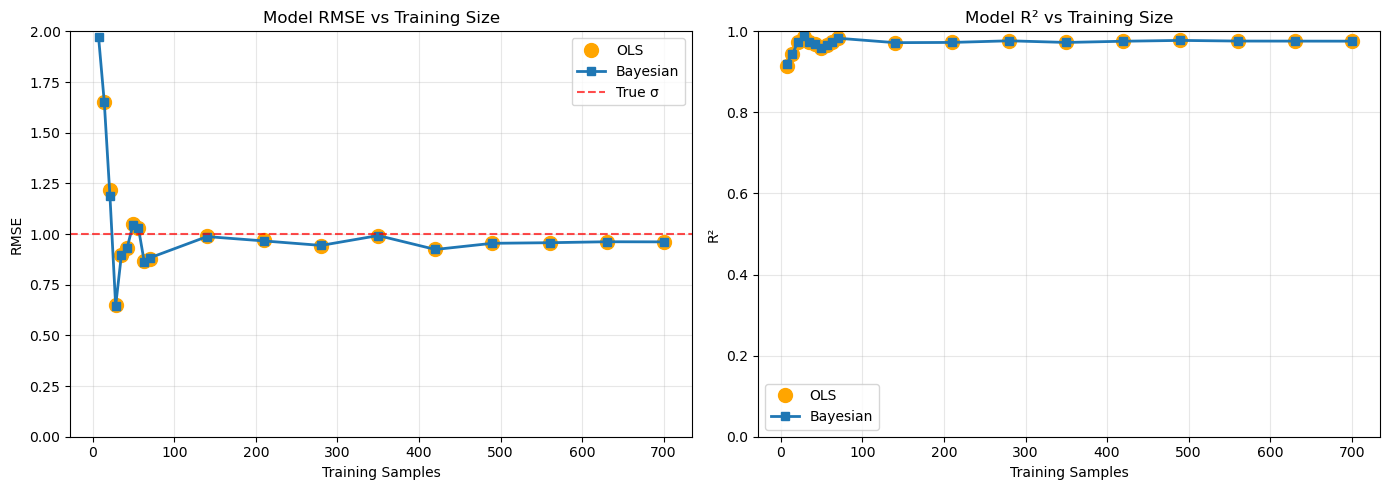

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_train_vals = [r['n_train'] for r in ols_results]

# RMSE comparison
axes[0].plot(n_train_vals, [r['rmse'] for r in ols_results], 
            marker='o', c='orange', ms=10,label='OLS', linewidth=0)
axes[0].plot(n_train_vals, [r['rmse'] for r in bayes_results], 
            marker='s', label='Bayesian', linewidth=2)
axes[0].axhline(y=np.sqrt(true_sigma2), color='red', linestyle='--', 
               label='True σ', alpha=0.7)
axes[0].set_ylim(0, 2)
axes[0].set_xlabel('Training Samples')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Model RMSE vs Training Size')
axes[0].legend()
axes[0].grid(alpha=0.3)

# R² comparison
axes[1].plot(n_train_vals, [r['r2'] for r in ols_results], 
            marker='o', color='orange', ms=10, label='OLS', linewidth=0)
axes[1].plot(n_train_vals, [r['r2'] for r in bayes_results], 
            marker='s', label='Bayesian', linewidth=2)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Training Samples')
axes[1].set_ylabel('R²')
axes[1].set_title('Model R² vs Training Size')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both models converge rapidly, approaching the true noise floor with relatively few samples. The R² metric reaches near-maximum values with approximately 50 training samples, suggesting diminishing returns for additional data in this well-behaved synthetic case.

### MCMC Convergence Analysis

Trace plots are examined at selected stages to assess chain convergence and burn-in adequacy. These diagnostics verify that the sampler has reached its stationary distribution.

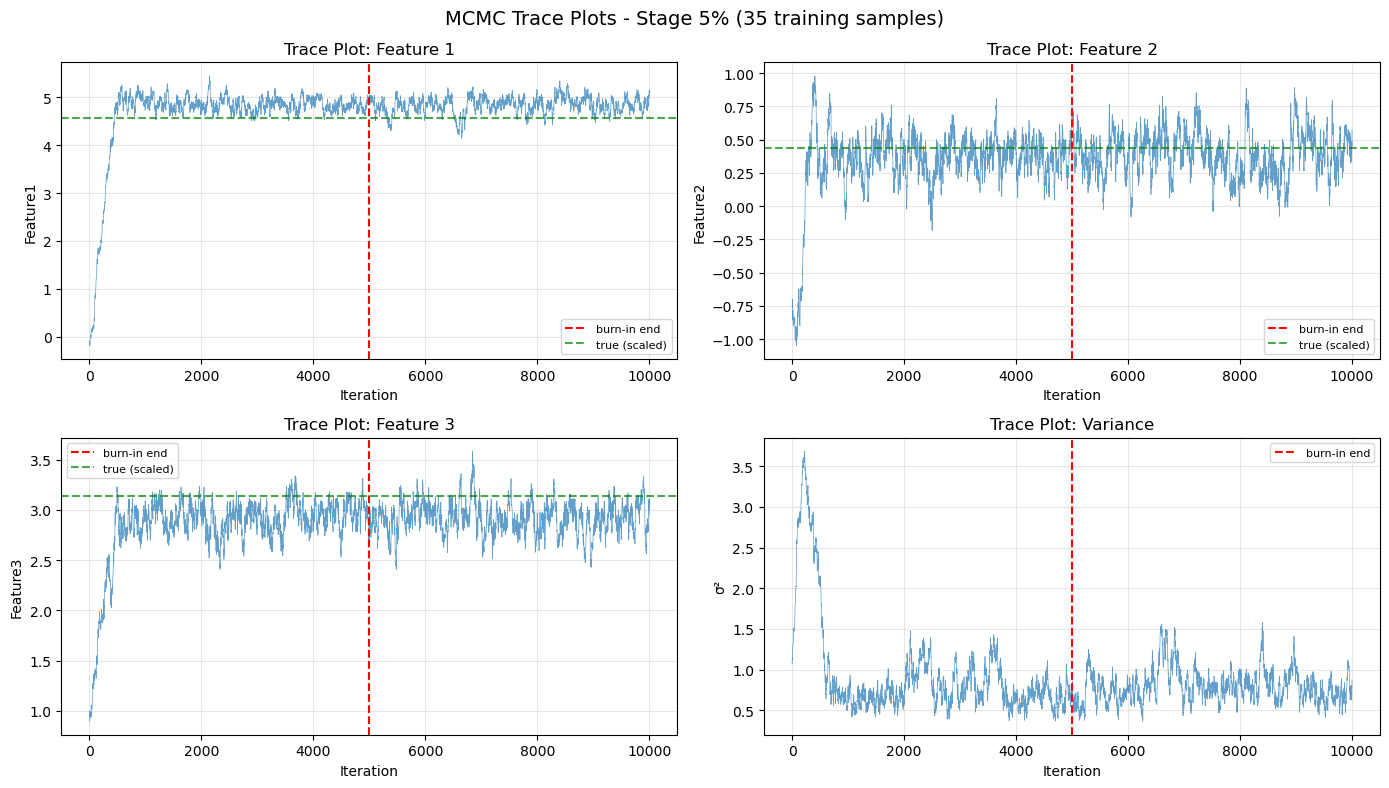

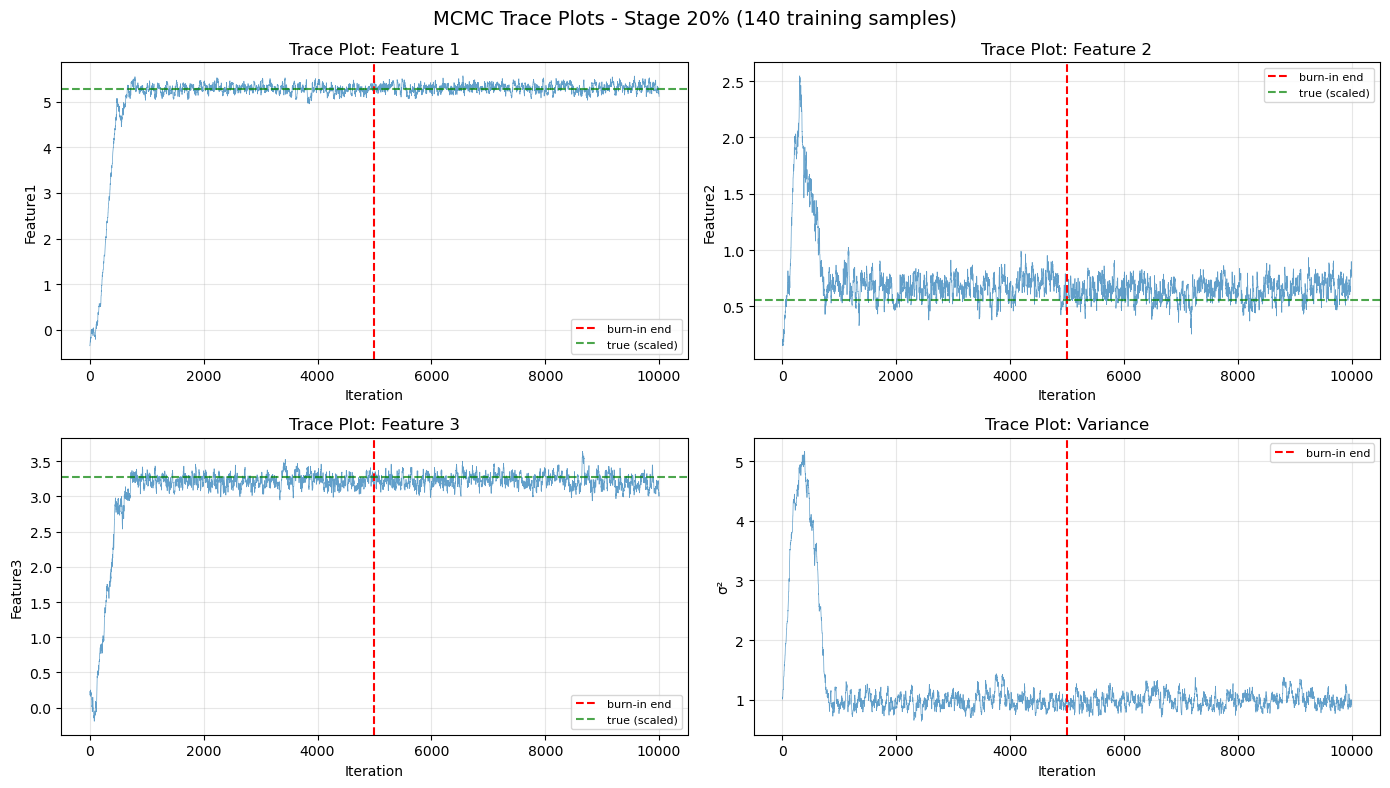

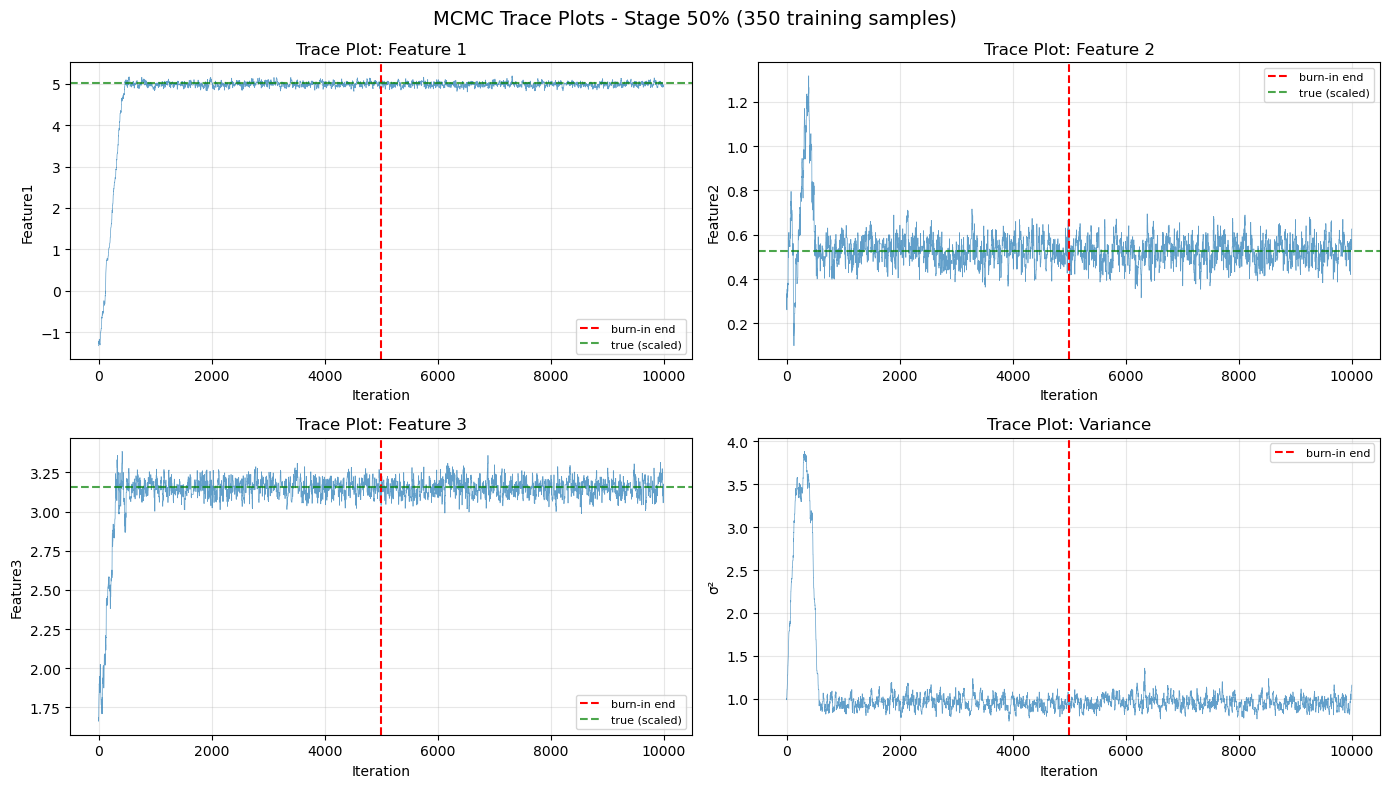

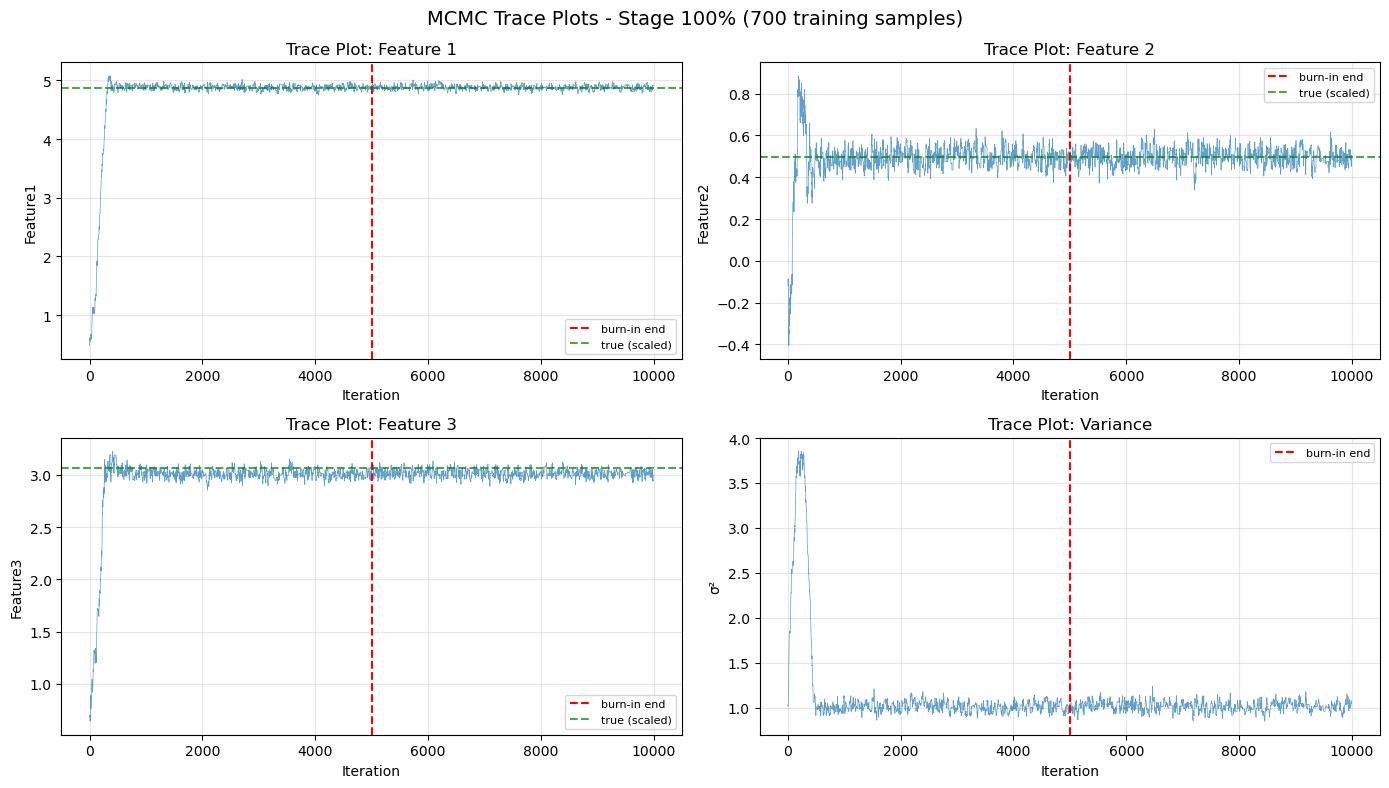

In [8]:
# show trace plots for early, middle, and late stages
selected_stages = [0.05, 0.2, 0.5, 1.0]

for stage_pct in selected_stages:
    idx = stages.index(stage_pct)
    result = bayes_results[idx]
    
    # use stored full chain from fitting
    beta_full = result['beta_full']
    sigma2_full = result['sigma2_full']
    n_burnin = result['n_burnin']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # trace plots for each beta
    for i in range(3):
        ax = axes[i//2, i%2]
        full_chain = beta_full[:, i+1]
        ax.plot(full_chain, alpha=0.7, linewidth=0.5)
        ax.axvline(x=n_burnin, color='red', linestyle='--', label='burn-in end')
        ax.axhline(y=result['true_beta_scaled'][i], color='green', 
                  linestyle='--', label='true (scaled)', alpha=0.7)
        ax.set_xlabel('Iteration')
        ax.set_ylabel(f'Feature{i+1}')
        ax.set_title(f'Trace Plot: Feature {i+1}')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    # sigma2 trace
    ax = axes[1, 1]
    ax.plot(range(len(sigma2_full)), sigma2_full, alpha=0.7, linewidth=0.5)
    ax.axvline(x=n_burnin, color='red', linestyle='--', label='burn-in end')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('σ²')
    ax.set_title('Trace Plot: Variance')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    plt.suptitle(f'MCMC Trace Plots - Stage {int(stage_pct*100)}% ' +
                f'({result["n_train"]} training samples)', fontsize=14)
    plt.tight_layout()
    plt.show()

### Parameter Evolution and Uncertainty

Coefficient estimates and confidence intervals are tracked across all stages to visualize how parameter uncertainty evolves with increasing sample size.

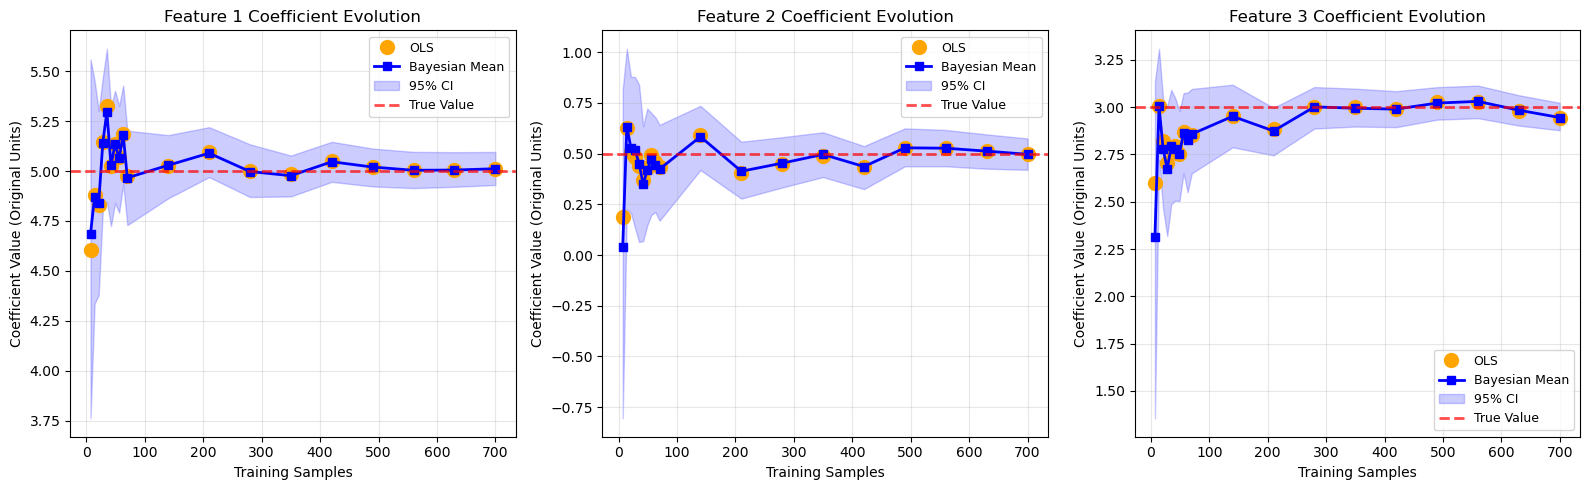

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for feat_idx in range(3):
    ax = axes[feat_idx]
    
    # transform OLS estimates back to original units
    ols_coefs_scaled = [r['beta'][feat_idx] for r in ols_results]
    ols_coefs = [c / ols_results[i]['scaler'].scale_[feat_idx] for i, c in enumerate(ols_coefs_scaled)]
    ax.plot(n_train_vals, ols_coefs, marker='o', ms=10, label='OLS', 
           linewidth=0, color='orange')
    
    # transform bayesian estimates back to original units
    means_scaled = [r['summary'].iloc[feat_idx+1]['Mean'] for r in bayes_results]
    ci_low_scaled = [r['summary'].iloc[feat_idx+1]['CI_2.5'] for r in bayes_results]
    ci_high_scaled = [r['summary'].iloc[feat_idx+1]['CI_97.5'] for r in bayes_results]
    
    means = [m / bayes_results[i]['scaler'].scale_[feat_idx] for i, m in enumerate(means_scaled)]
    ci_low = [c / bayes_results[i]['scaler'].scale_[feat_idx] for i, c in enumerate(ci_low_scaled)]
    ci_high = [c / bayes_results[i]['scaler'].scale_[feat_idx] for i, c in enumerate(ci_high_scaled)]
    
    ax.plot(n_train_vals, means, marker='s', label='Bayesian Mean', 
           linewidth=2, color='blue')
    ax.fill_between(n_train_vals, ci_low, ci_high, alpha=0.2, 
                    label='95% CI', color='blue')
    

    
    # true parameter (original units - constant across stages)
    ax.axhline(y=true_beta[feat_idx], color='red', linestyle='--', 
               label='True Value', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Coefficient Value (Original Units)')
    ax.set_title(f'Feature {feat_idx+1} Coefficient Evolution')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

As sample size increases, both models converge toward true parameter values. Notably, the Bayesian confidence intervals narrow systematically, providing quantitative evidence of improving certainty with additional data.

### Posterior Distributions

Full posterior distributions are visualized at representative stages (5%, 20%, 50%, 100% of data) to illustrate the evolution of parameter uncertainty.

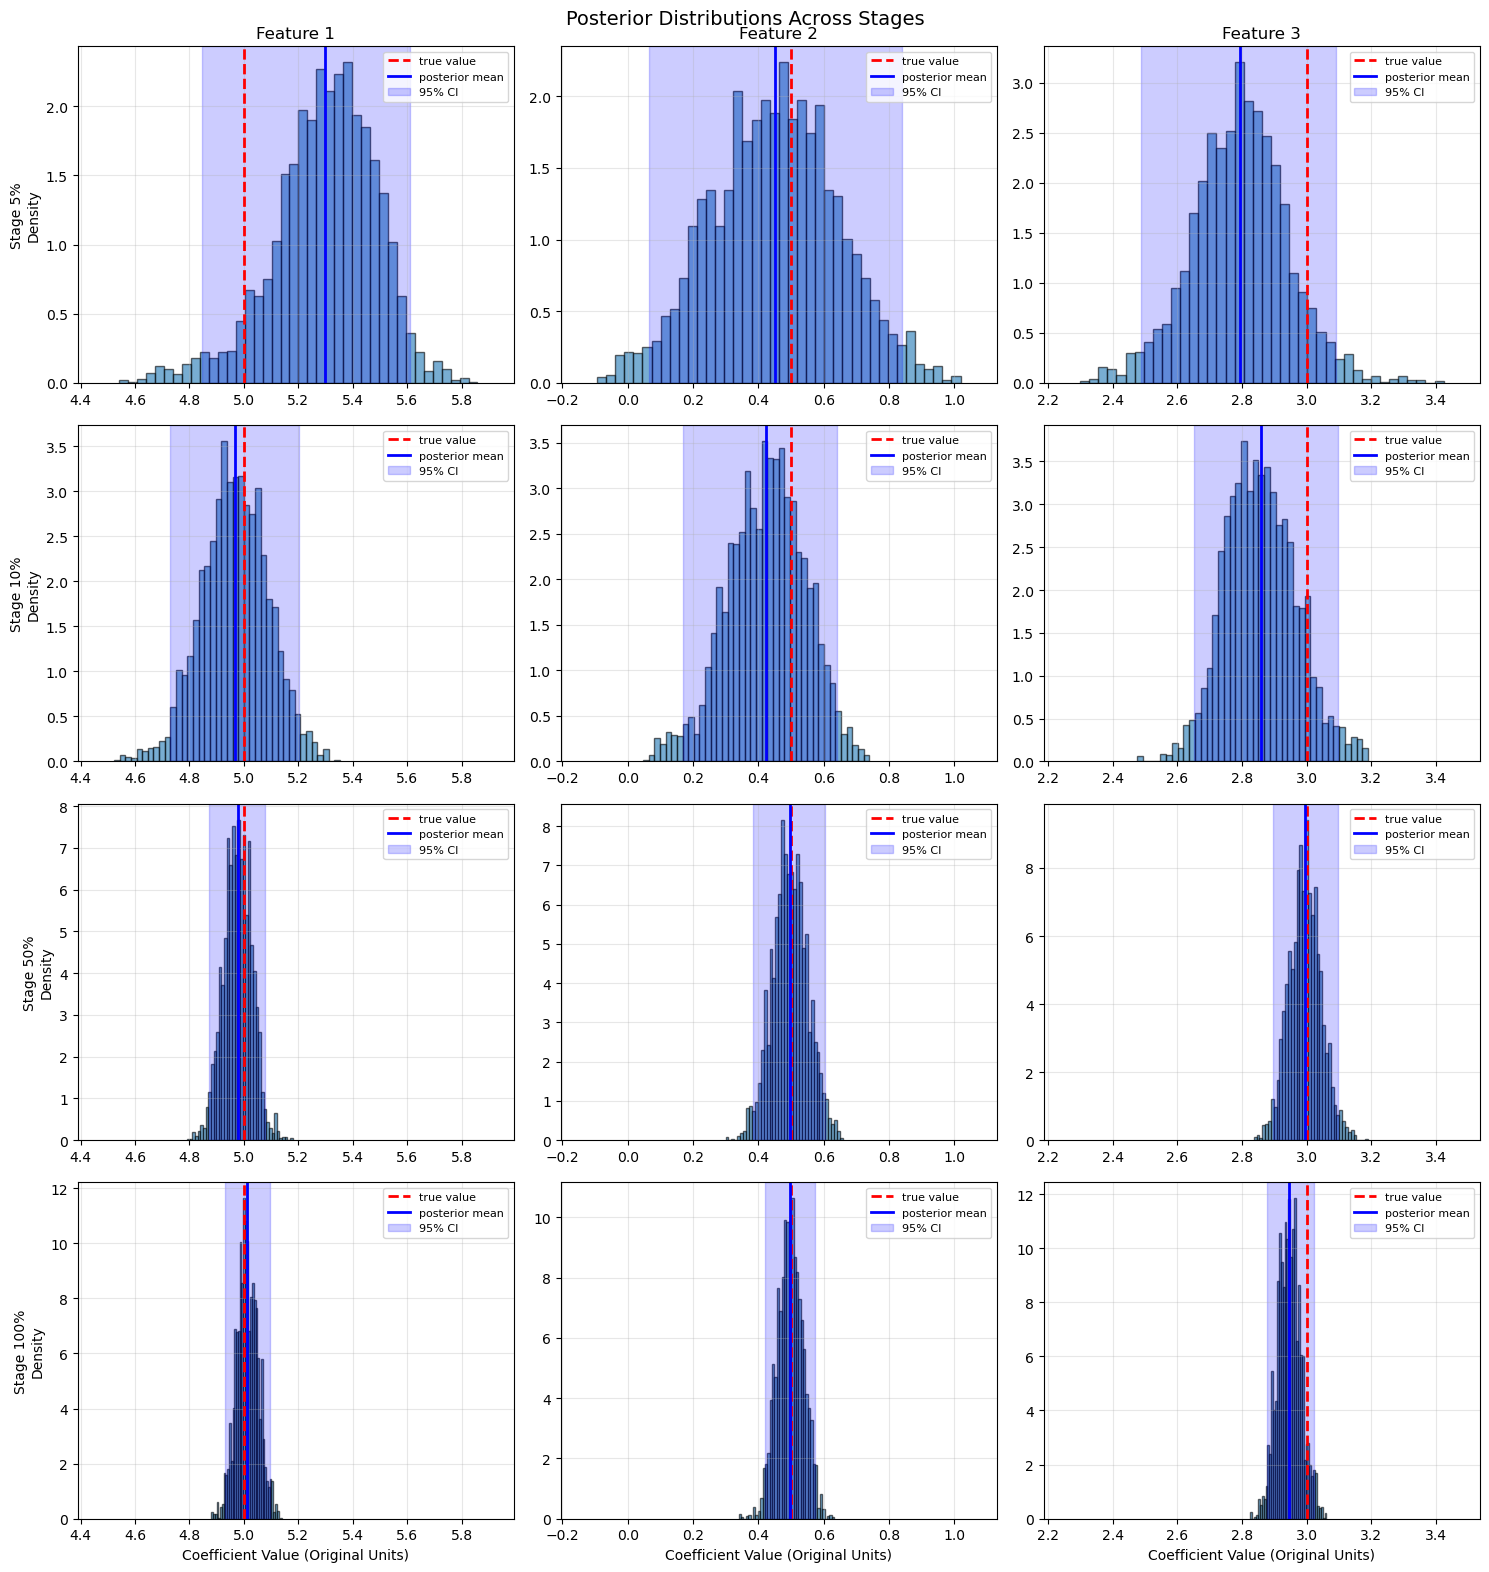

In [10]:
selected_stages_idx = [4, 9, 13, 18]  # 5%, 20%, 50%, 100%

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

# calculate x-axis limits for each feature in original units across all stages
xlims = []
for col in range(3):
    all_samples_original = []
    for stage_idx in selected_stages_idx:
        result = bayes_results[stage_idx]
        samples_scaled = result['beta_samples'][:, col+1]
        # transform back to original units
        samples_original = samples_scaled / result['scaler'].scale_[col]
        all_samples_original.extend(samples_original)
    
    # set limits based on overall range with some padding
    x_min, x_max = np.min(all_samples_original), np.max(all_samples_original)
    x_range = x_max - x_min
    xlims.append((x_min - 0.1*x_range, x_max + 0.1*x_range))

for row, stage_idx in enumerate(selected_stages_idx):
    result = bayes_results[stage_idx]
    stage_pct = result['stage']
    
    for col in range(3):
        ax = axes[row, col]
        
        # transform posterior samples back to original units
        samples_scaled = result['beta_samples'][:, col+1]
        samples_original = samples_scaled / result['scaler'].scale_[col]
        
        # plot posterior
        ax.hist(samples_original, bins=40, density=True, alpha=0.6, edgecolor='black')
        
        # add true value (original units)
        true_val = true_beta[col]
        ax.axvline(x=true_val, color='red', linestyle='--', 
                  linewidth=2, label='true value')
        
        # add mean and CI
        mean_val = samples_original.mean()
        ci = np.percentile(samples_original, [2.5, 97.5])
        ax.axvline(x=mean_val, color='blue', linestyle='-', 
                  linewidth=2, label='posterior mean')
        ax.axvspan(ci[0], ci[1], alpha=0.2, color='blue', label='95% CI')
        
        # set consistent x limits for each column
        ax.set_xlim(xlims[col])
        
        if row == 0:
            ax.set_title(f'Feature {col+1}', fontsize=12)
        if col == 0:
            ax.set_ylabel(f'Stage {int(stage_pct*100)}%\nDensity', fontsize=10)
        if row == 3:
            ax.set_xlabel('Coefficient Value (Original Units)', fontsize=10)
        
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.suptitle('Posterior Distributions Across Stages', fontsize=14)
plt.tight_layout()
plt.show()

From the above distributions it is clear that:
- Confidence in the modeled parameters increase (the C.I. is smaller) as more data is included to the model
- The posterior mean approaches the true value with more data
- Note that with very little data, confidence in the true model parameter is low and not near the posterior mean!

### Discussion

The workflow demonstrates several key findings about Bayesian regression:

1. **Convergence behavior**: Both OLS and Bayesian models achieve similar performance and stablize with ~70 training data.

2. **Uncertainty quantification**: The Bayesian approach provides full posterior distributions for parameters, not just point estimates. We can visualize uncertainty and for decision making think of this in context of percentiles (P10, P50, P90, etc.) depending on the context.

3. **MCMC convergence**: The Metropolis-Hastings sampler shows consistent burn-in behavior across stages, typically stabilizing after 1000 samples with an extremely naive prior (~0)

4. **Predictive accuracy**: Both methods achieve comparable predictive accuracy!

5. **Practical implications**: For subsurface applications where decision-making requires understanding parameter uncertainty (e.g., reserve estimation, production forecasting), the Bayesian framework provides valuable additional information. The ability to track how uncertainty evolves through time as new data is acquired supports more informed risk assessment.

### About the Author

Ryan McGuigan is a graduate student in the Hildebrand Department of Petroleum and Geosystems Engineering at The University of Texas at Austin, focusing on subsurface data analytics and machine learning applications in energy systems. This workflow was developed as part of the Subsurface Machine Learning course to demonstrate practical implementation of Bayesian inference methods.

For questions or collaboration opportunities, feel free to reach out via [LinkedIn](https://www.linkedin.com/in/ryan-mcguigan).

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)